In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/bibekacharya/.cache/kagglehub/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/versions/1


# Employee Churn Prediction - EDA

In [3]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split


In [4]:
data=pd.read_csv('/Users/bibekacharya/Documents/Documents/Machine_Learning/Machine_Learning_projects/Logistic_Regression/Data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df=data.copy()


### Quick Glance 


In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [6]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,Y,No,12,3,1,80,0,6,3,4,4,3,1,2


In [7]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [8]:
df['MaritalStatus'].unique()

array(['Single', 'Married', 'Divorced'], dtype=object)

In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [13]:
df['Attrition'].unique()

array(['Yes', 'No'], dtype=object)

In [14]:
df['Attrition'].value_counts() # imp later do determine what label encoder did 

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [15]:
df['JobSatisfaction'].unique() 

array([4, 2, 3, 1])

4 is the highest level of satisfaction 

In [16]:
df['EmployeeCount'].unique()

array([1])

In [17]:
df['EmployeeNumber']
 # dosent really give much info 

0          1
1          2
2          4
3          5
4          7
        ... 
1465    2061
1466    2062
1467    2064
1468    2065
1469    2068
Name: EmployeeNumber, Length: 1470, dtype: int64

In [18]:
df['Over18'].unique(),df['StandardHours'].unique()

(array(['Y'], dtype=object), array([80]))

In [19]:
df.drop(['StandardHours','Over18','EmployeeNumber','EmployeeCount'],axis=1,inplace=True)
# removed col that couldnt give us much info about data.

###  Univariate-Analysis on data

Text(0.5, 1.0, 'Attrition status')

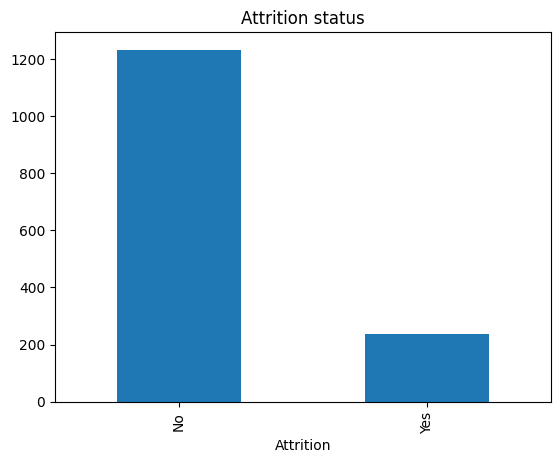

In [20]:
df['Attrition'].value_counts().plot(kind='bar')
plt.title('Attrition status')

More people stayed than they left 

Text(0.5, 1.0, 'How much do employees earn?')

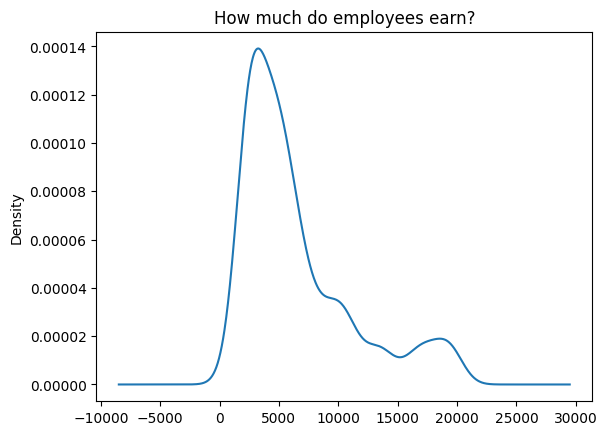

In [21]:
df['MonthlyIncome'].plot(kind='kde')
plt.title('How much do employees earn?')

mostly, employee earn between 5k to 10k a month. 

In [22]:
df['MonthlyIncome'].mean()

np.float64(6502.931292517007)

Text(0.5, 1.0, 'How often Employee travel for work?')

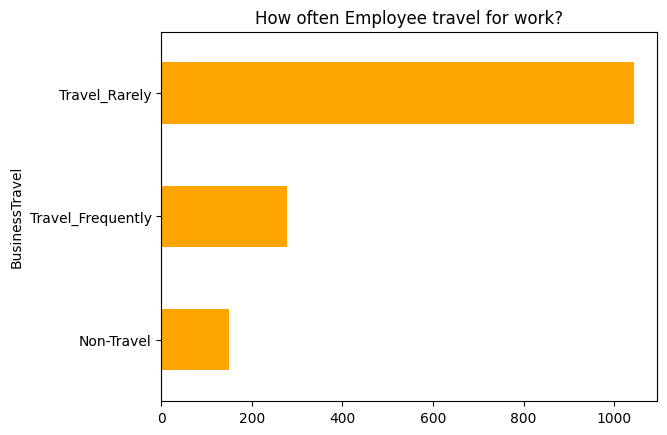

In [23]:
df['BusinessTravel'].value_counts(ascending=True).plot(kind='barh',color='orange')
plt.title('How often Employee travel for work?')

Text(0.5, 1.0, 'What Level of Education Employee hold?')

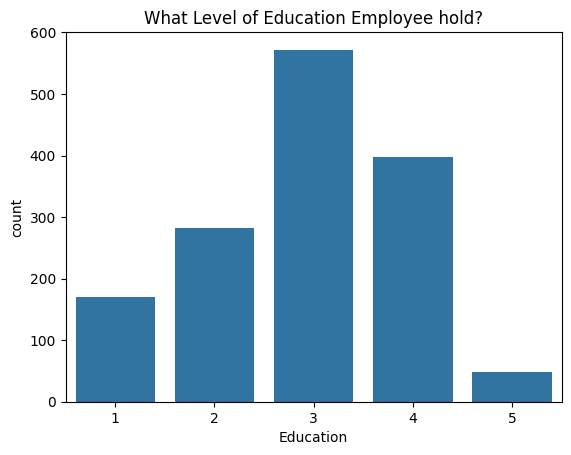

In [24]:
# how educated are the employees ? 

sns.countplot(data=df, x='Education')
plt.title('What Level of Education Employee hold?')

As per the information given in the data : Education is defined as: 
1 :'Below College'
2 :'College'
3 :'Bachelor'
4 :'Master'
5 :'Doctor'

>> so most of the employee hold Undergrade Degree. There are also few employee who have education below college. And very Few have 'PHD' degrees 

Text(0.5, 1.0, 'For how long employee have been working?')

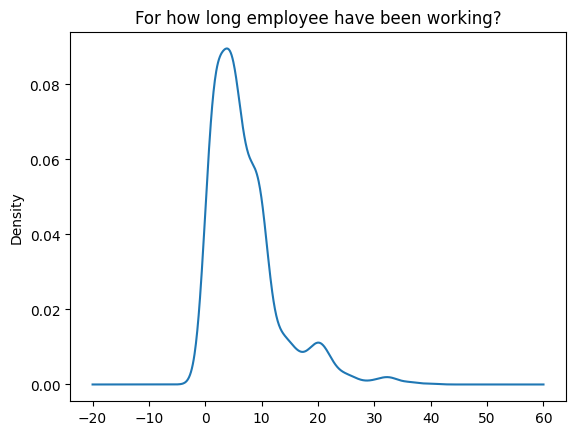

In [25]:
# how long have employee been with the compnay ? 
df['YearsAtCompany'].plot(kind='kde')
plt.title('For how long employee have been working?')

SO mostly employee have been working with the compnay around 7-8 years. Some have been working past 30 too. Thats a huge amount of time spent by employee 

In [26]:
df['YearsAtCompany'].mean()

np.float64(7.0081632653061225)

so mean age people have been working for the company is around 7 years 

<Axes: xlabel='count', ylabel='JobRole'>

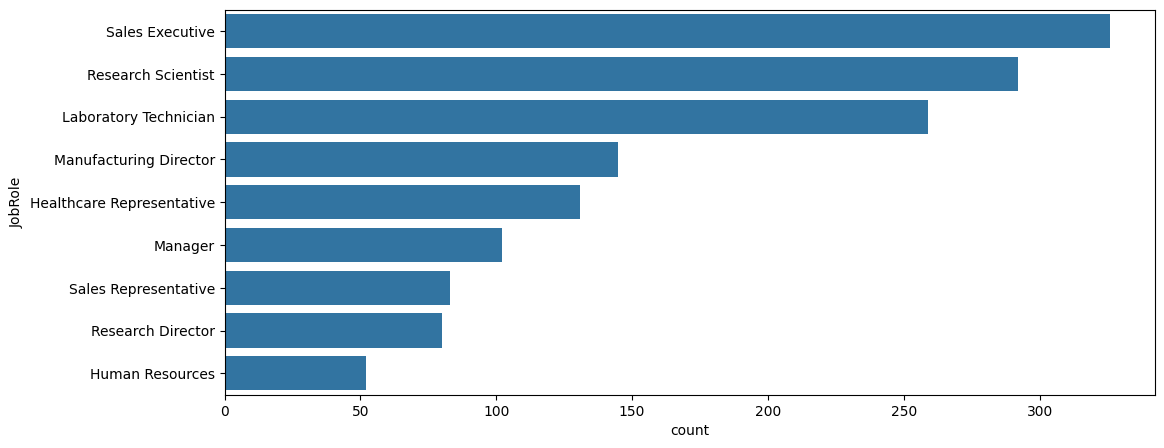

In [27]:
# what job role employee mostly hold in the compnay ? 

plt.figure(figsize=(12,5))
sns.countplot(data=df, y='JobRole')

so,people mostly work as a Sales Executive in the company. Followed by Research Scientists.   
very few people work as HR. 

In [28]:
# lets expore what department are there in company 

df['Department'].unique()

array(['Sales', 'Research & Development', 'Human Resources'], dtype=object)

<Axes: xlabel='Gender', ylabel='count'>

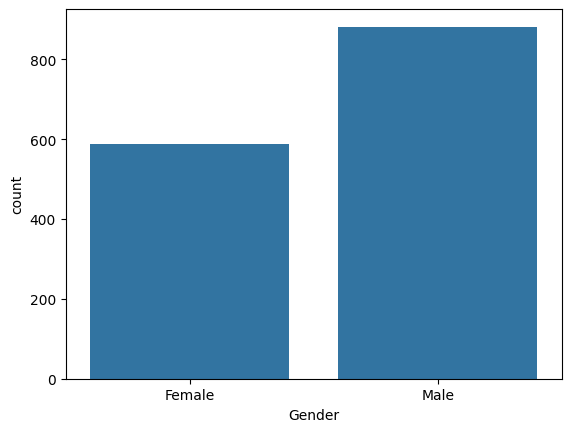

In [29]:
sns.countplot(data=df, x='Gender')


So,There are more Male workers in the company. More than 800 (around the range of 1k ) are Male employees and nearly 600 are female employees 

### Bivariate-Analysis
- we will use 2 or more column to find realtions, information from data 

##### Let's Answer some HR & Business Questions

In [30]:
df.head(0)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


Text(0.5, 1.0, 'Which Gender do more Overtime?')

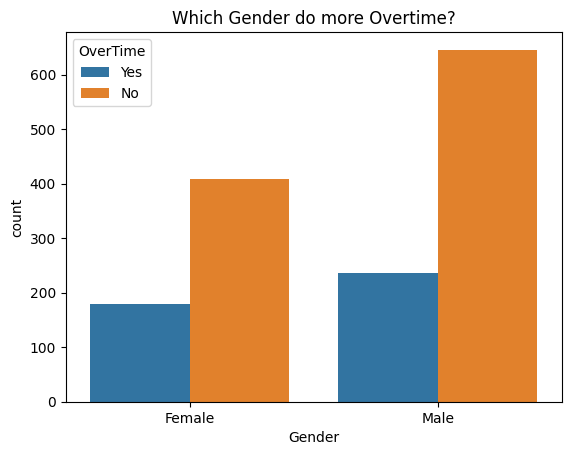

In [31]:
sns.countplot(data=df, x='Gender', hue='OverTime')
plt.title('Which Gender do more Overtime?')

This has 2 sides:

1. Male do More overtime than Female. Also, we have more male employee in the compnay 

In [32]:
pd.crosstab(
    df['Gender'],
    df['OverTime'],
    normalize='index'
) * 100

OverTime,No,Yes
Gender,,
Female,69.387755,30.612245
Male,73.242630,26.757370


Among male and female doing overtime, Female (30%) usally do more overtime than male (27%). 
>>simply, Among within Population of male and female, Female do more worktime among female than male 

Text(0.5, 1.0, 'Which department provides more salary in the compnay?')

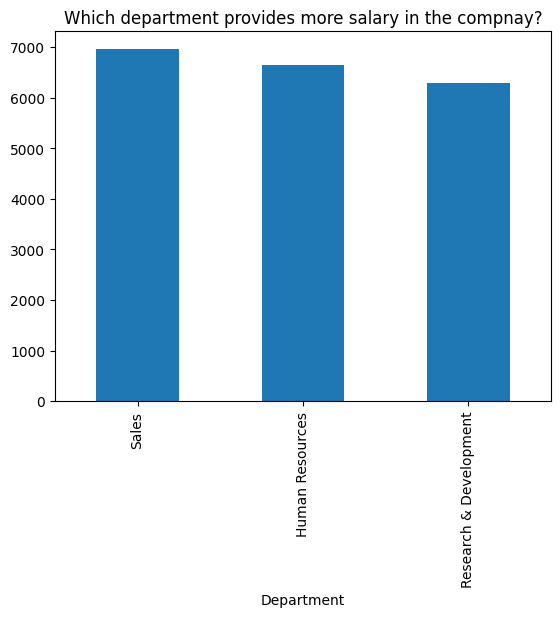

In [33]:
# Which department provides more salary in the compnay ?

df.groupby('Department')['MonthlyIncome'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Which department provides more salary in the compnay?')


Sales has the highest average monthly salary (≈ $6,959), followed by Human Resources (≈ $6,655). Research & Development has the lowest average monthly salary (≈ $6,281). This suggests that employees in the Sales department earn more on average than those in the other departments.

Text(0.5, 1.0, 'which are the highest paying roles in the company ?? ')

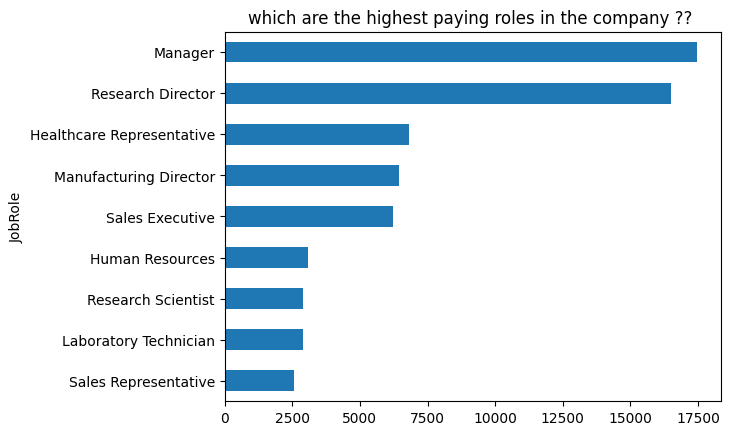

In [34]:
# which are the top 3 highest paying role in the company ?? 
df.groupby('JobRole')['MonthlyIncome'].median().sort_values(ascending=True).plot(kind='barh')
plt.title('which are the highest paying roles in the company ?? ')

The Manager has the highest median salary $17454.5, followed by Research Director $16510.0, Healthcare Representative $6811.0   
The least is of Sales Representative $2579.0

In [35]:
# higher education means higher salary ? 


df['Education'].corr(df['MonthlyIncome'])

np.float64(0.09496067704188875)

Text(0.5, 1.0, 'higher education means higher salary ? ')

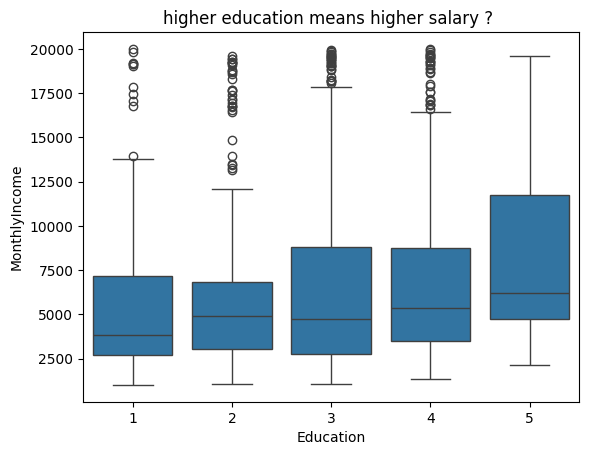

In [36]:
sns.boxplot(data=df, x='Education', y='MonthlyIncome')
plt.title('higher education means higher salary ? ')

The presence of outliers in every education group indicates that some employees earn significantly higher salaries than others despite having the same education level. This suggests that education alone does not determine salary. Other factors such as job level, job role, years of experience, department, or performance may also influence an employee’s income.

Text(0.5, 1.0, 'Are salary and Job Satisfaction realted')

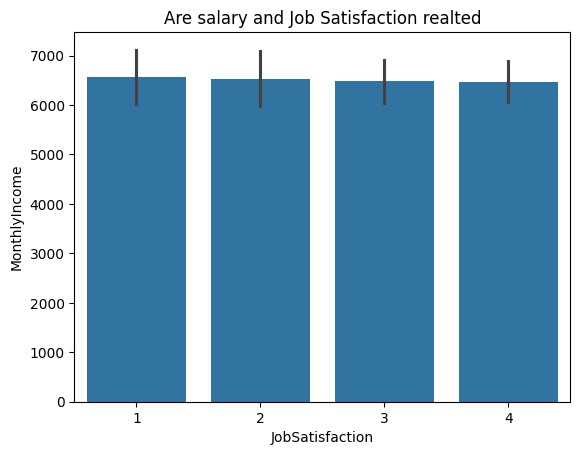

In [37]:
# Are job satisfaction and salary related?
sns.barplot(data=df, x='JobSatisfaction', y='MonthlyIncome')
plt.title('Are salary and Job Satisfaction realted')

The average monthly income is very similar across all job satisfaction levels. Based on this analysis, there does not appear to be a strong relationship between job satisfaction and salary. Employees with both low and high job satisfaction earn comparable average salaries.

In [38]:
df.groupby('JobSatisfaction')['MonthlyIncome'].mean()

JobSatisfaction
1    6561.570934
2    6527.328571
3    6480.495475
4    6472.732026
Name: MonthlyIncome, dtype: float64

/var/folders/7r/6c5w6tr551b0q1_3l2f2q4ph0000gn/T/ipykernel_94920/2165689362.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Age'], bins=[18,30,40,50,60]))['MonthlyIncome'].mean().plot(kind='bar')


Text(0.5, 1.0, 'Are older employees Paid more ?')

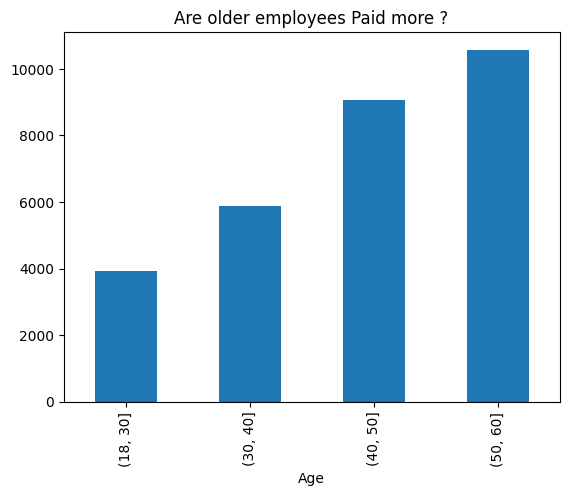

In [39]:
df.groupby(pd.cut(df['Age'], bins=[18,30,40,50,60]))['MonthlyIncome'].mean().plot(kind='bar')
plt.title('Are older employees Paid more ?')

Looking at the plot, we grouped age into diffrent bins in increasing age order and we can clearly see the as the age bin increases the salary also increases .. 

### Let's Answer some Attrition questions 

In [40]:
df.head(0)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [41]:
# Does lowe job satisfaction lead to higher Attrition
pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


Employees with lower job satisfaction are more likely to leave the company.

<Axes: xlabel='Attrition', ylabel='WorkLifeBalance'>

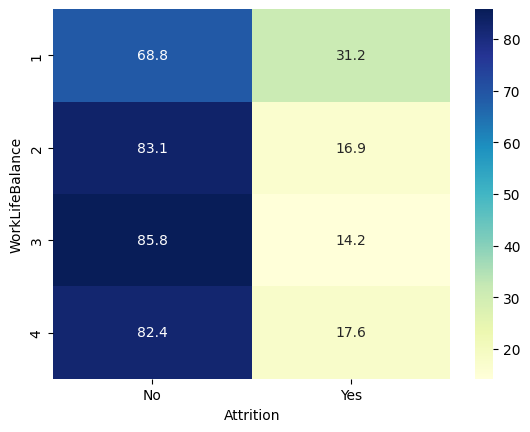

In [42]:
 # Do employees with lower work-life balance leave more?

ct=pd.crosstab(df['WorkLifeBalance'],df['Attrition'],normalize='index')*100


sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlGnBu')

WorkLifeBalance as per dataset info :  
- 1 'Bad'
- 2 'Good'
- 3 'Better'
- 4 'Best' 


mployees with poor work-life balance are more likely to leave the company. The highest attrition rate is observed at WorkLifeBalance level 1 (31.2%). Employees with moderate to high work-life balance have considerably lower attrition rates (14–18%), suggesting that better work-life balance is associated with improved employee retention.

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

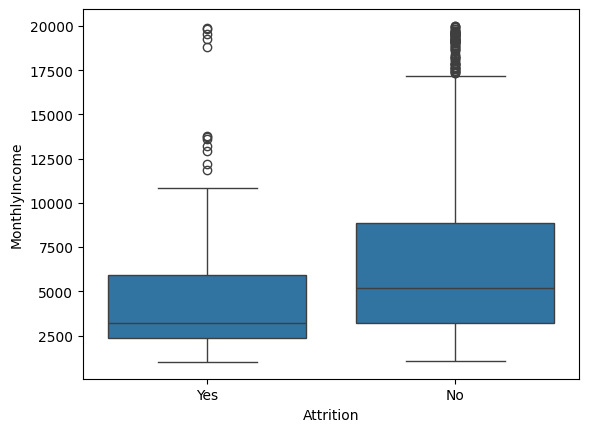

In [43]:
# Does monthly income affect attrition?

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')

The boxplot shows that employees who did not leave the company generally have higher monthly incomes than those who did. The median monthly income is higher for the non-attrition group, while employees who left tend to have lower and less variable incomes. Both groups contain high-income outliers, although these are more common among employees who stayed. Overall, the plot suggests a negative relationship between monthly income and attrition—employees with higher salaries appear less likely to leave—but income alone does not fully explain employee turnover due to the overlap between the two distributions.

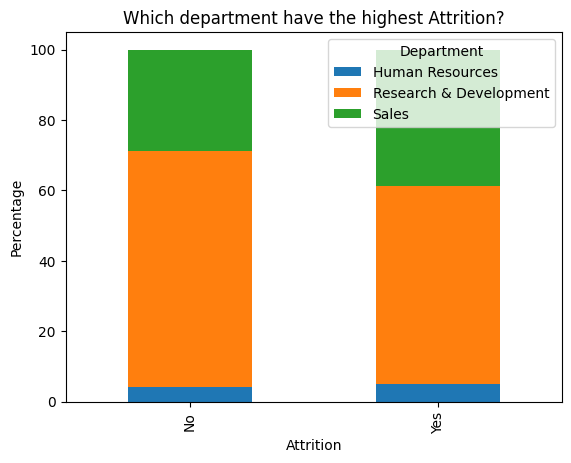

In [44]:
# Which departments have the highest attrition?
ct=pd.crosstab(df['Attrition'],df['Department'],normalize='index')*100


ct.plot(kind='bar', stacked=True)

plt.ylabel("Percentage")
plt.title('Which department have the highest Attrition?')
plt.show()

Reso we can conclude that,  research & development department had the highest attrition about 60% followed by Sales Department around 29%

In [45]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


In [46]:
''' BusinessTravel , education field, Gender, MaritialStatus,jobrole are nominal category(we cant order them )
 so we will apply OHE, 

for Attrition we will labelencode it .  '''

' BusinessTravel , education field, Gender, MaritialStatus,jobrole are nominal category(we cant order them )\n so we will apply OHE, \n\nfor Attrition we will labelencode it .  '

In [47]:


from sklearn.preprocessing import LabelEncoder,OneHotEncoder

label = LabelEncoder()
df['Attrition'] = label.fit_transform(df['Attrition'])

X = df.drop('Attrition', axis=1)
y = df['Attrition']


In [48]:
df.shape

(1470, 31)

In [49]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
X_train.shape,X_test.shape

((1176, 30), (294, 30))

In [51]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# sacale only numerical col 

cat_cols = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'OverTime'
]


num_cols = [col for col in X.columns if col not in cat_cols]


pipe1=ColumnTransformer(transformers=[
    ('tnf1',OneHotEncoder(sparse_output=False, handle_unknown='ignore'),['OverTime','Gender','MaritalStatus','BusinessTravel','Department','EducationField','JobRole']),
   ('scale',StandardScaler(),num_cols)],remainder='passthrough')


In [52]:
''' X_train_transformed=encode.fit_transform(X_train)
X_test_transformed=encode.transform(X_test)


# fit() means learn. it should only learn from train data  

X_train_transformed.shape
X_test_transformed.shape
''' 


# we will make use of pipeling so no need to do this manualy as pipleing will internally handle it 

' X_train_transformed=encode.fit_transform(X_train)\nX_test_transformed=encode.transform(X_test)\n\n\n# fit() means learn. it should only learn from train data  \n\nX_train_transformed.shape\nX_test_transformed.shape\n'

In [53]:
# pd.DataFrame(X_train_transformed)

In [54]:
from sklearn.linear_model import LogisticRegression
pipe2=LogisticRegression( ) # yes/no binary class so no need of softmax/multinomial reg


In [55]:
from sklearn.pipeline import make_pipeline
pipe=make_pipeline(pipe1,pipe2)
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tnf1', ...), ('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of t

In [ ]:
df['Attrition'].value_counts() 

# label encoder sorts class alphabetically so no came before yes 

Attrition
0    1233
1     237
Name: count, dtype: int64

In [56]:

y_pred = pipe.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [71]:
y_pred_probab=pipe.predict_proba(X_test)
y_pred_probab

array([[9.38494160e-01, 6.15058398e-02],
       [9.96629972e-01, 3.37002821e-03],
       [6.38114548e-01, 3.61885452e-01],
       [9.89545396e-01, 1.04546039e-02],
       [9.53642759e-01, 4.63572408e-02],
       [6.92399623e-01, 3.07600377e-01],
       [6.13010871e-01, 3.86989129e-01],
       [9.63019176e-01, 3.69808241e-02],
       [9.36220792e-01, 6.37792077e-02],
       [9.84619660e-01, 1.53803397e-02],
       [5.04604116e-01, 4.95395884e-01],
       [9.50315351e-01, 4.96846493e-02],
       [9.10848948e-01, 8.91510516e-02],
       [9.59686620e-01, 4.03133804e-02],
       [9.75419243e-01, 2.45807571e-02],
       [9.06281135e-01, 9.37188650e-02],
       [8.25871251e-01, 1.74128749e-01],
       [8.74662663e-01, 1.25337337e-01],
       [7.82371276e-01, 2.17628724e-01],
       [9.50164950e-01, 4.98350496e-02],
       [4.64245184e-01, 5.35754816e-01],
       [9.96697870e-01, 3.30212984e-03],
       [9.58748599e-01, 4.12514010e-02],
       [6.00912273e-01, 3.99087727e-01],
       [8.722146

In [82]:
attrition_yes_probab=pipe.predict_proba(X_test)[:,1] # who left
attrition_no_probab=pipe.predict_proba(X_test)[:,0] # who left 
attrition_yes_probab 

array([6.15058398e-02, 3.37002821e-03, 3.61885452e-01, 1.04546039e-02,
       4.63572408e-02, 3.07600377e-01, 3.86989129e-01, 3.69808241e-02,
       6.37792077e-02, 1.53803397e-02, 4.95395884e-01, 4.96846493e-02,
       8.91510516e-02, 4.03133804e-02, 2.45807571e-02, 9.37188650e-02,
       1.74128749e-01, 1.25337337e-01, 2.17628724e-01, 4.98350496e-02,
       5.35754816e-01, 3.30212984e-03, 4.12514010e-02, 3.99087727e-01,
       1.27785337e-01, 2.38296105e-02, 7.83931598e-02, 8.78933694e-03,
       8.67533689e-02, 3.52991629e-02, 9.16894331e-03, 2.53513507e-03,
       2.04411580e-03, 2.46400150e-02, 5.39641044e-01, 3.94802165e-03,
       5.92217486e-04, 2.38493882e-01, 8.38083738e-01, 1.79145590e-02,
       4.76144249e-02, 1.20182676e-01, 4.29017961e-02, 5.22402507e-02,
       7.02213443e-01, 8.64419246e-03, 7.92499620e-01, 5.53076990e-01,
       5.04771835e-01, 5.04640993e-01, 1.02200689e-02, 1.44399993e-01,
       7.97413672e-03, 8.30373072e-02, 1.21752946e-01, 8.81922036e-02,
      

In [83]:
attrition_no_probab

array([0.93849416, 0.99662997, 0.63811455, 0.9895454 , 0.95364276,
       0.69239962, 0.61301087, 0.96301918, 0.93622079, 0.98461966,
       0.50460412, 0.95031535, 0.91084895, 0.95968662, 0.97541924,
       0.90628114, 0.82587125, 0.87466266, 0.78237128, 0.95016495,
       0.46424518, 0.99669787, 0.9587486 , 0.60091227, 0.87221466,
       0.97617039, 0.92160684, 0.99121066, 0.91324663, 0.96470084,
       0.99083106, 0.99746486, 0.99795588, 0.97535999, 0.46035896,
       0.99605198, 0.99940778, 0.76150612, 0.16191626, 0.98208544,
       0.95238558, 0.87981732, 0.9570982 , 0.94775975, 0.29778656,
       0.99135581, 0.20750038, 0.44692301, 0.49522817, 0.49535901,
       0.98977993, 0.85560001, 0.99202586, 0.91696269, 0.87824705,
       0.9118078 , 0.59067552, 0.9985872 , 0.95657019, 0.88258775,
       0.96663275, 0.49043199, 0.97271216, 0.9991479 , 0.81906047,
       0.41011785, 0.98121774, 0.86750278, 0.99045341, 0.83447143,
       0.80564617, 0.91933936, 0.72502717, 0.94277576, 0.93941

In [58]:
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,precision_score

accuracy_score(y_test,y_pred)

0.8945578231292517

In [59]:
confusion_matrix(y_test,y_pred,labels=[1,0])

array([[ 18,  21],
       [ 10, 245]])

In [60]:
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

Attrition
No     1233
Yes     237
Name: count, dtype: int64   as we did .value_count() above before encoding .

Label/class are also imbalanced .  
>>with 1,233 employees staying and only 237 leaving. Therefore, accuracy alone may be misleading. 

> In this business problem, the more critical error is a False Negative (FN), where an employee is actually going to leave but the model predicts they will stay. Such employees may not receive timely  efforts from HR/company, resulting in unexpected attrition. Since the model produced 21 False Negatives, recall for the attrition class is an important evaluation metric and will be considered alongside accuracy.

In [61]:
recall_score(y_test,y_pred)

0.46153846153846156

In [62]:
precision_score(y_test,y_pred)

0.6428571428571429


##### The baseline Logistic Regression model achieved 89.45% accuracy. However, the recall for the attrition class was only 46.2%, meaning the model correctly identified only 18 out of 39 employees who actually left the company. Since missing employees who are likely to leave (False Negatives) is a more critical business risk, a class-balanced Logistic Regression model was further explored to improve recall.


We will make a slight change to the previous pipeline. The preprocessing step (pipe1) will remain the same, where the data is encoded and scaled.Only the model part will be changed. new pipeline will be created using 'classed based logistic model', and its performance will be compared with the Logistic Regression model.

In [63]:

pipe4=LogisticRegression(class_weight='balanced',max_iter=1000)# class_weight='balanced' automatically gives more importance to the minority class (1).

pipe_new=make_pipeline(pipe1,pipe4)

pipe_new.fit(X_train, y_train)

cls_pred = pipe_new.predict(X_test)

In [64]:
cls_pred

array([0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0])

In [78]:

cls_pred_probab=pipe_new.predict_proba(X_test)
cls_pred_probab

array([[7.44757128e-01, 2.55242872e-01],
       [9.73642132e-01, 2.63578675e-02],
       [2.48410678e-01, 7.51589322e-01],
       [9.51224893e-01, 4.87751066e-02],
       [8.08551209e-01, 1.91448791e-01],
       [2.79662917e-01, 7.20337083e-01],
       [2.92656140e-01, 7.07343860e-01],
       [8.58612930e-01, 1.41387070e-01],
       [6.08420656e-01, 3.91579344e-01],
       [9.37407482e-01, 6.25925175e-02],
       [2.12831565e-01, 7.87168435e-01],
       [7.34289548e-01, 2.65710452e-01],
       [6.80889589e-01, 3.19110411e-01],
       [8.43302544e-01, 1.56697456e-01],
       [8.87402616e-01, 1.12597384e-01],
       [6.30116447e-01, 3.69883553e-01],
       [5.80863915e-01, 4.19136085e-01],
       [7.01474659e-01, 2.98525341e-01],
       [5.53423280e-01, 4.46576720e-01],
       [8.18495879e-01, 1.81504121e-01],
       [1.75345256e-01, 8.24654744e-01],
       [9.74999045e-01, 2.50009554e-02],
       [8.25494740e-01, 1.74505260e-01],
       [2.86770177e-01, 7.13229823e-01],
       [5.803737

In [65]:
accuracy_score(y_test,cls_pred)

0.7142857142857143

In [66]:
confusion_matrix(y_test,cls_pred,labels=[1,0])

array([[ 22,  17],
       [ 67, 188]])

In [67]:
recall_score(y_test,cls_pred)

0.5641025641025641

In [68]:
precision_score(y_test,cls_pred)

0.24719101123595505

In [85]:
from sklearn.metrics import roc_curve

fpr,tpr,threshold=roc_curve(y_test,attrition_yes_probab)
threshold

array([           inf, 9.11211304e-01, 7.62791297e-01, 7.24122622e-01,
       7.02213443e-01, 6.82023124e-01, 6.57004531e-01, 6.31999050e-01,
       5.89882146e-01, 5.67532885e-01, 5.35754816e-01, 5.18844973e-01,
       5.04640993e-01, 4.99388733e-01, 4.95696346e-01, 3.77607637e-01,
       3.61885452e-01, 2.42438998e-01, 2.38493882e-01, 2.27509623e-01,
       2.17628724e-01, 2.01148660e-01, 1.97009340e-01, 1.82602181e-01,
       1.79552329e-01, 1.72836840e-01, 1.70372596e-01, 1.62025956e-01,
       1.60355729e-01, 1.42723811e-01, 1.36985260e-01, 1.26359092e-01,
       1.25337337e-01, 1.05730650e-01, 1.03554572e-01, 1.01982522e-01,
       9.57523187e-02, 6.05883061e-02, 5.98323005e-02, 4.48078222e-02,
       4.42954648e-02, 2.89439095e-02, 2.72878423e-02, 2.72347329e-02,
       2.66022569e-02, 1.79145590e-02, 1.69190814e-02, 5.23045555e-03,
       4.83778365e-03, 2.53513507e-03, 2.42765924e-03, 1.98313704e-04])

Since the more critical business error is a False Negative—where an employee is actually going to leave but the model predicts they will stay—we focus on recall for the attrition class. The baseline Logistic Regression model achieved a recall of 46.15%, while the class-balanced Logistic Regression model achieved a higher recall of 56.41%. Although the balanced model has lower overall accuracy, it identifies more employees who are likely to leave. Therefore, the class-balanced Logistic Regression model was selected as the final model for this project.

In [70]:
import joblib

joblib.dump(pipe_new, 'employee_attrition_pipeline.pkl')
#joblib is generally preferred for scikit-learn pipelines because it handles large NumPy arrays efficiently.

['employee_attrition_pipeline.pkl']